# Airline Passenger Satisfaction Prediction

## Model Interpretation

### Objective

This notebook, I'm trying to answer a specific question: why did Random Forest beat Logistic Regression by such a big margin last time (99.3% vs. 90.8% ROC-AUC)? That's a much bigger gap than I expected, and I don't think "Random Forest is just generally better" is a satisfying enough answer so I want to actually understand what Logistic Regression is missing.

My guess going in is that some of these service ratings might have a non-linear relationship with satisfaction. A linear model can't pick up on that kind of pattern no matter how much data you give it, while a tree-based model handles it natively.

**This notebook covers:**
1. Permutation importance (a trustworthy alternative to Random Forest's built-in importance)
2. AUnderstanding why the linear model underperformed, checking whether the top features actually have a non-linear relationship with satisfaction
3. Business recommendations based on what actually came out of the analysis
4. Final conclusions, limitations, and future work


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

import shap

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


### Load the model and reconstruct the test set

Same split as the training notebook, reproduced from the saved feature CSV so I'm looking at the same held-out passengers the model was actually evaluated on.

In [2]:
with open("../models/trained_model.pkl", "rb") as f:
    model = pickle.load(f)

df_unscaled = pd.read_csv("../data/processed/airline_satisfaction_features.csv")
X = df_unscaled.drop(columns=["satisfaction"])
y = df_unscaled["satisfaction"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Loaded model:", type(model).__name__)
print("Test shape:", X_test.shape)


Loaded model: RandomForestClassifier
Test shape: (25898, 23)


### Permutation importance

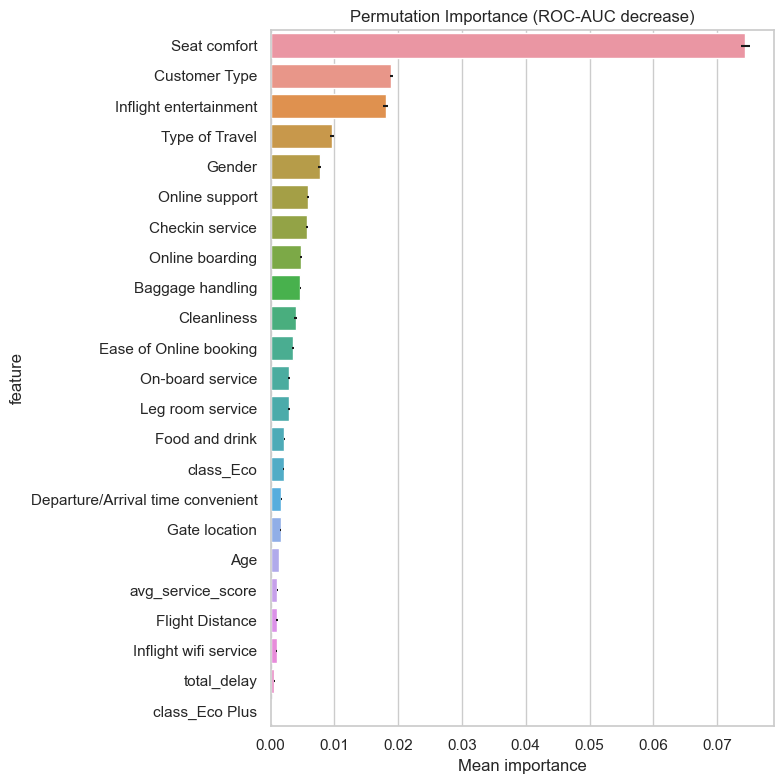

,feature,importance_mean,importance_std
5,Seat comfort,0.074410,0.000743
1,Customer Type,0.018946,0.000225
10,Inflight entertainment,0.018090,0.000392
3,Type of Travel,0.009630,0.000317
0,Gender,0.007718,0.000205
11,Online support,0.005876,0.000176
16,Checkin service,0.005686,0.000169
18,Online boarding,0.004773,0.000164
15,Baggage handling,0.004694,0.000145
17,Cleanliness,0.003951,0.000198


In [3]:
perm_result = permutation_importance(
    model, X_test, y_test, scoring="roc_auc",
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(data=perm_importance_df, x="importance_mean", y="feature",
            xerr=perm_importance_df["importance_std"])
plt.title("Permutation Importance (ROC-AUC decrease)")
plt.xlabel("Mean importance")
plt.tight_layout()
plt.savefig("../images/permutation_importance.png", dpi=300, bbox_inches="tight")
plt.show()

perm_importance_df


Okay, this is a really different picture than the quick impurity-based look from the last notebook. Seat comfort is now the clear number 1, and by a wide margin its importance (0.074) is almost 4x the next feature. In the previous notebook's quick look, Inflight entertainment was number 1 and Seat comfort was number 2, here they've essentially swapped, with Inflight entertainment dropping to number 3.

Also interesting, Customer Type and Type of Travel jump up to 2nd and 4th here, even though neither stood out much in the earlier impurity-based chart. That's a meaningful correction, so it means the quick-look ranking from the last notebook wasn't just slightly off, it was highlighting some features that don't actually matter as much for real predictive performance, while underselling others that do.

### Understanding the linear vs. non-linear question

This is the main thing I want to figure out here. For each of the top features from permutation importance, I'm plotting the actual satisfaction rate at every rating value (0 through 5). If a feature has a clean, roughly straight-line relationship with satisfaction, Logistic Regression should handle it fine. If the relationship bends, plateaus, or isn't monotonic, that's exactly the kind of pattern only a tree-based model can pick up on and would explain a chunk of the performance gap.

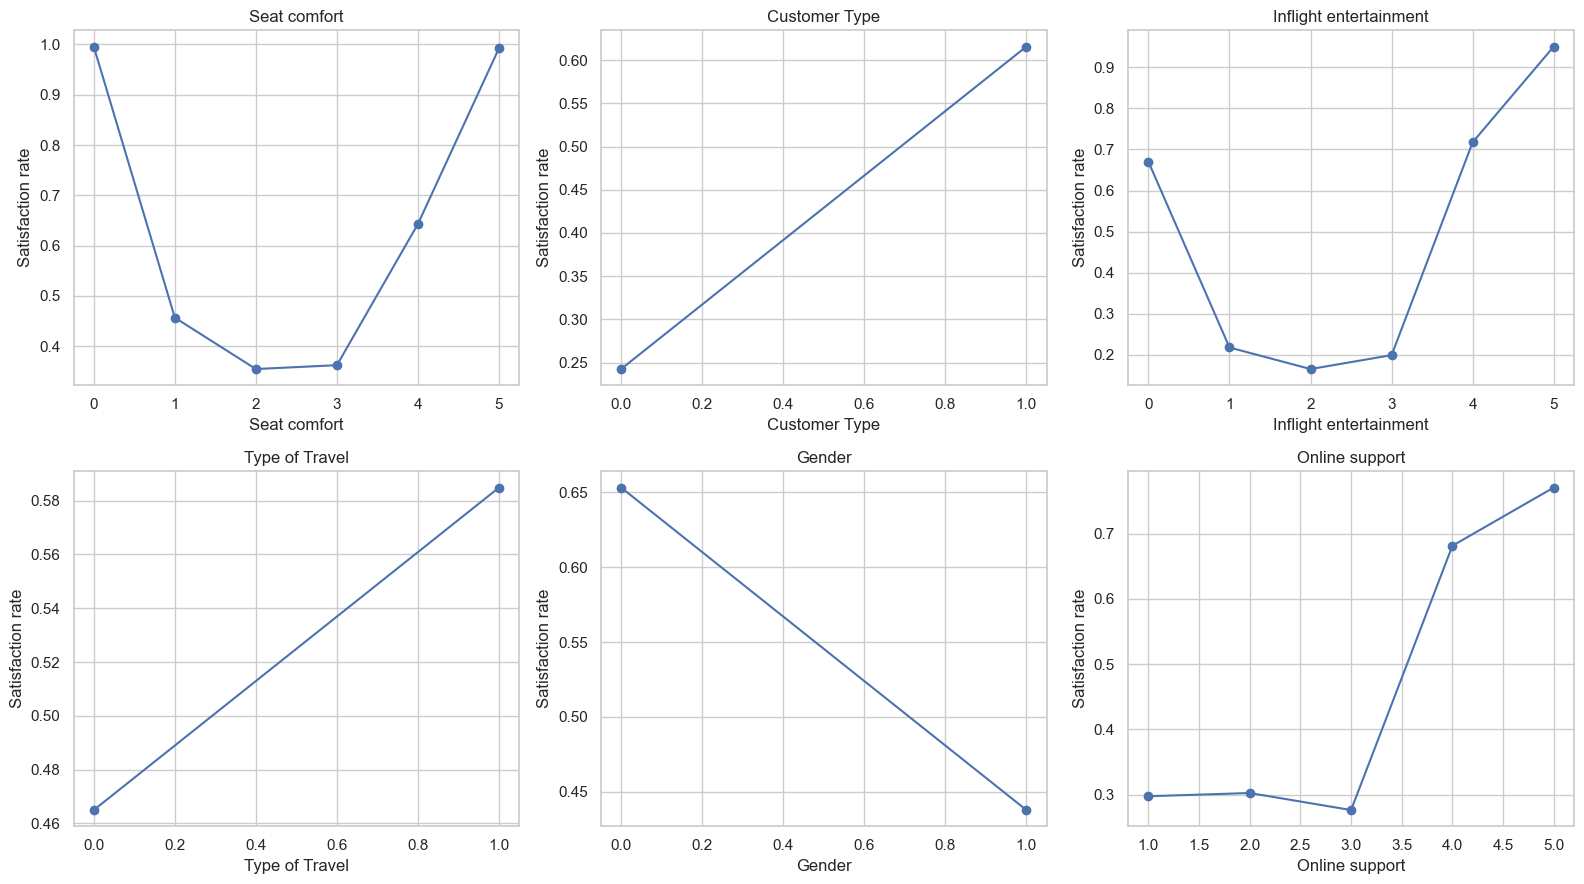

In [4]:
top_features = perm_importance_df["feature"].head(6).tolist()

check_df = X_test.copy()
check_df["satisfaction"] = y_test.values

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, feature in zip(axes, top_features):
    # Only plot this way for features with a small number of distinct values
    # (ratings, binary flags); continuous features like Age get a different treatment
    if check_df[feature].nunique() <= 10:
        rate_by_value = check_df.groupby(feature)["satisfaction"].mean()
        ax.plot(rate_by_value.index, rate_by_value.values, marker="o")
        ax.set_title(feature)
        ax.set_xlabel(feature)
        ax.set_ylabel("Satisfaction rate")
    else:
        ax.hist(check_df[feature], bins=30)
        ax.set_title(f"{feature} (continuous — see distribution)")

plt.tight_layout()
plt.savefig("../images/top_feature_linearity_check.png", dpi=300, bbox_inches="tight")
plt.show()


This is the answer I was looking for. Two of the features **Seat comfort** and **Inflight entertainment** both show a clear U-shape, not a steady climb. Satisfaction starts high at a rating of 0, drops sharply through ratings 1-3, then climbs back up at 4-5. A rating of 0 is behaving like a 5, not like "worse than 1" which makes sense if 0 actually represents passengers who didn't experience or didn't rate that service, rather than genuinely rating it as the worst possible score. A linear model has no way to represent that, it can only assign one direction and one slope to a feature, so it can't say "0 is good, 1-3 is bad, 4-5 is good", it has to pick some kind of straight-line compromise that ends up being wrong for a big chunk of passengers either way.

Online support tells a slightly different but related story it's not U-shaped, but it is a threshold effect. Satisfaction sits flat around 0.3 for ratings 1 through 3, then jumps sharply to 0.68 at a rating of 4 and 0.75 at 5. Again, a linear model would treat the jump from 3 to 4 the same as the jump from 1 to 2, when in reality almost all the actual signal is concentrated in that one specific jump.

Customer Type, Type of Travel, and Gender, on the other hand, all show clean, roughly monotonic relationships exactly the kind of pattern Logistic Regression should have no trouble with. So it's specifically the service *rating* features carrying non-linear patterns, not the demographic ones.

This is a solid explanation for a real chunk of that 99.3% vs. 90.8% gap, the two strongest predictive features in the whole dataset happen to be ones a linear model is structurally unable to represent correctly.

### A note on SHAP

I originally planned to include SHAP values here too, but the linearity check above already answered my main question of whether some of these features have a non-linear relationship with satisfaction and permutation importance gave me a reliable importance ranking on its own. Given that, and how long SHAP was taking to run on a test set this size, I decided it wasn't worth the extra runtime for what it would've added here. Worth revisiting if I want a more detailed, per passenger explanation down the line.

## Business Recommendations

1. **Investigate what a rating of 0 actually means for Seat comfort and Inflight entertainment.** Given that passengers who gave a 0 are just as satisfied as those who gave a 5, it's likely that 0 represents "didn't use/not applicable" rather than "worst possible experience." If that's confirmed, future surveys should separate "not applicable" from the actual 0-5 rating scale, conflating the two is actively misleading anyone reading these ratings as a simple average.

2. **For Online support, the real opportunity is getting ratings from 3 to 4, not from 1 to 2.** Since satisfaction barely moves until a rating hits 4, incremental improvements that nudge scores from "poor" to "mediocre" won't show up in the numbers, the payoff is specifically in pushing support experiences from "good" to "great."

3. **Loyalty and travel type both show a clean, meaningful relationship with satisfaction** disloyal customers and personal-travel passengers are consistently more likely to be dissatisfied. These are good, low-ambiguity targets for retention-style outreach, since the relationship isn't complicated by any threshold or non-monotonic effect.

4. **Don't prioritize gate location or departure/arrival time convenience.** Both showed almost no relationship with satisfaction across the EDA, feature engineering, and now permutation importance, consistently near the bottom every time. Resources are better spent elsewhere.


## Final Conclusions

The main question driving this notebook was why did Random Forest beat Logistic Regression by such a wide margin, now has a clear answer: the two strongest predictive features (Seat comfort and Inflight entertainment) both have a U-shaped, non-monotonic relationship with satisfaction, most likely because a rating of 0 represents "didn't use this service" rather than "worst possible experience." A linear model has no way to represent that pattern correctly, no matter how much data it sees, while Random Forest picks it up naturally.

Permutation importance also meaningfully corrected the picture from the quick impurity-based look in the last notebook. Seat comfort turned out to be the dominant feature by a wide margin, not Inflight entertainment, and Customer Type and Type of Travel turned out to matter more than the quick look suggested. This is a good reminder that Random Forest's built-in importance shouldn't be trusted at face value.

Beyond the model itself, this points to a real data quality issue worth flagging, the "0" rating on these service categories is doing double duty as both a rating and a "not applicable" flag, and that ambiguity is exactly what tripped up the linear model.


## Limitations

- **No causal claims.** Permutation importance shows what the model relies on, not necessarily what actually causes satisfaction in the real world. A passenger who's already satisfied for other reasons might also rate individual services more generously, correlation running in both directions is hard to rule out with survey data like this.

- **Survey data has its own biases.** Passengers who bothered to fill out the survey may not represent all passengers equally, and self-reported satisfaction and self-reported service ratings could be influenced by the same underlying mood rather than being independent signals.

- **No temporal validation.** This is a random split, not a time-based one, no check on whether the model would hold up on future survey responses, especially if service quality or passenger expectations shift over time.

- **Uncalibrated probabilities.** Random Forest's predict_proba() output isn't guaranteed to reflect true probabilities without calibration, worth keeping in mind if these scores are ever used for anything beyond ranking.

- **Limited scope.** This dataset only covers a single airline's survey responses; the findings might not generalize to other airlines or regions.


## Future Work

- **Follow up on the 0-rating finding directly** check whether a 0 genuinely means "not applicable" in this dataset's documentation, and if so, re-encode it as a separate missing-value flag rather than treating it as part of the 0-5 scale. This could close a real chunk of the gap for Logistic Regression, since it would remove the U-shape rather than requiring the model to work around it.

- **Try XGBoost or another boosting model** to see if it can match or beat Random Forest's performance, and whether it points to the same top features.

- **Calibrate the model's probabilities**, so they could be used directly (e.g. to flag passengers most at risk of a bad experience) rather than just for ranking.

- **A/B test the top business recommendation** to see if acting on it actually moves satisfaction, rather than relying on the model's word for it.
